# MDM GANAI Activity 1
## Industry-Level Image Generation System using Autoencoder + VAE & GAN-Based Synthetic Image Generation Platform

---

### Project Overview & Industry Problem Statement
* **Industry Motivation**:
  - **Fashion-Tech Use Case**: A fashion-tech company requires an AI-powered fashion image generation and representation system. The system learns visual characteristics, textures, and contours of clothing images to synthesize realistic, novel clothing designs.
  - **Digital-Design Use Case**: A digital-design company aims to reduce product photography and asset rendering costs. The generative platform creates high-fidelity synthetic fashion images for **product design ideation**, **marketing prototypes**, **synthetic dataset augmentation**, and **creative experimentation**.
* **Subject**: `MDM GANAI Activity 1`
* **Team Members**:
  - **Aryan Kumar** — `202301070164`
  - **Amir Furquani** — `202301070165`

---

### Generative Adversarial Network (GAN) Framework
Generative Adversarial Networks (Goodfellow et al., 2014) pit two deep neural networks against each other in a game-theoretic minimax framework:
1. **The Generator ($G$)**: Learns a continuous mapping from a stochastic latent prior $z \sim \mathcal{N}(0, I_{100})$ to synthetic fashion images $G(z) \in \mathbb{R}^{784}$ ($28 \times 28$ grayscale pixels).
2. **The Discriminator ($D$)**: A classifier estimating probability $D(x) \in [0, 1]$ that sample $x$ comes from the true training distribution $p_{\text{data}}$ rather than $G$.

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$


In [1]:
# ==============================================================================
# Environment Configuration & Hardware Acceleration Verification
# ==============================================================================
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Set Keras backend to PyTorch for native CUDA GPU acceleration on Windows
os.environ["KERAS_BACKEND"] = "torch"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning framework imports (Keras & TensorFlow)
import keras
from keras.layers import Dense, Dropout, Input, ReLU
from keras.models import Model, Sequential
from keras.optimizers import Adam
import tensorflow as tf
import torch

print("=" * 65)
print("SYSTEM & HARDWARE ACCELERATION STATUS")
print("=" * 65)
print(f"• TensorFlow Version  : {tf.__version__}")
print(f"• Keras Version       : {keras.__version__} (Backend: {keras.backend.backend()})")
print(f"• PyTorch Version     : {torch.__version__}")
print(f"• GPU Acceleration    : {'AVAILABLE' if torch.cuda.is_available() else 'CPU ONLY'}")
if torch.cuda.is_available():
    print(f"• Active GPU Device   : {torch.cuda.get_device_name(0)}")
    print(f"• Total VRAM          : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
print("=" * 65)


SYSTEM & HARDWARE ACCELERATION STATUS
• TensorFlow Version  : 2.21.0
• Keras Version       : 3.12.1 (Backend: torch)
• PyTorch Version     : 2.7.1+cu118
• GPU Acceleration    : AVAILABLE
• Active GPU Device   : NVIDIA GeForce RTX 3050 6GB Laptop GPU
• Total VRAM          : 6.00 GB


### Data Ingestion & Preprocessing
* **Strict Training Isolation**: `fashion-mnist_train.csv` (60,000 images) is used entirely for model training with **no splitting**, while `fashion-mnist_test.csv` (10,000 images) is kept completely unseen until final model evaluation.
* **Feature Normalization**: Raw pixel values $[0, 255]$ are normalized to the symmetrical range $[-1, 1]$:
$$\tilde{x} = \frac{x - 127.5}{127.5}$$


In [2]:
# ==============================================================================
# Data Ingestion: Fashion-MNIST Train & Test Sets
# ==============================================================================
train_path = "fashion-mnist_train.csv"
test_path = "fashion-mnist_test.csv"

print(f"Loading training data from {train_path}...")
train_df = pd.read_csv(train_path)

print(f"Loading test data from {test_path} (kept completely unseen)...")
test_df = pd.read_csv(test_path)

# Extract labels and feature matrices
y_train = train_df["label"].values
x_train_raw = train_df.drop(["label"], axis=1).values

y_test = test_df["label"].values
x_test_raw = test_df.drop(["label"], axis=1).values

# Normalize pixel values to range [-1.0, 1.0] for stable adversarial gradient flow
x_train = (x_train_raw.astype(np.float32) - 127.5) / 127.5
x_test = (x_test_raw.astype(np.float32) - 127.5) / 127.5

print("\n" + "=" * 65)
print("DATASET PROFILE")
print("=" * 65)
print(f"• Training Set (x_train) : {x_train.shape} (Range: [{x_train.min():.1f}, {x_train.max():.1f}])")
print(f"• Unseen Test Set (x_test): {x_test.shape} (Range: [{x_test.min():.1f}, {x_test.max():.1f}])")
print(f"• Number of Classes      : {len(np.unique(y_train))}")
print("=" * 65)


Loading training data from fashion-mnist_train.csv...
Loading test data from fashion-mnist_test.csv (kept completely unseen)...

DATASET PROFILE
• Training Set (x_train) : (60000, 784) (Range: [-1.0, 1.0])
• Unseen Test Set (x_test): (10000, 784) (Range: [-1.0, 1.0])
• Number of Classes      : 10


### Exploratory Data Visualization: Sample Across All Fashion Categories
Below, we extract and display a clean representative sample for **all 10 categories** present in the Fashion-MNIST training data with corresponding human-readable apparel designations.


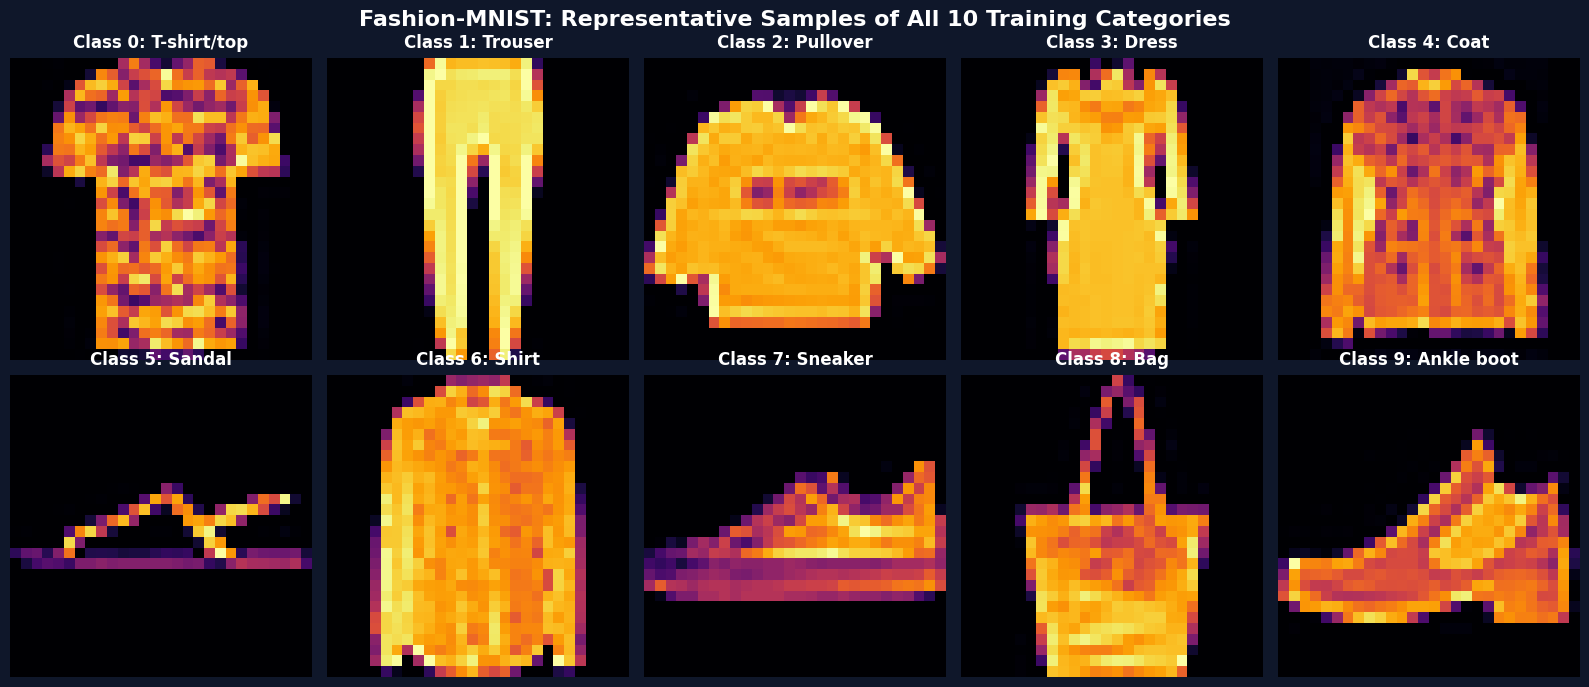

In [3]:
# ==============================================================================
# Visualizing Representative Samples of All 10 Apparel Categories
# ==============================================================================
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

fig, axs = plt.subplots(2, 5, figsize=(16, 7))
fig.patch.set_facecolor('#0f172a')

for class_idx, ax in enumerate(axs.flat):
    sample_idx = np.where(y_train == class_idx)[0][0]
    img = x_train[sample_idx].reshape(28, 28)
    
    im = ax.imshow(img, cmap='inferno', interpolation='nearest')
    ax.set_title(f"Class {class_idx}: {class_names[class_idx]}", color='white', fontsize=12, fontweight='bold', pad=8)
    ax.axis('off')

plt.suptitle("Fashion-MNIST: Representative Samples of All 10 Training Categories", 
             fontsize=16, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()


### Generative Adversarial Network Architecture
The network topology adheres strictly to the required Deep GAN architecture:

1. **Generator Network ($G$)**:
   - $\text{Input}(100) \rightarrow \text{Dense}(512) \rightarrow \text{ReLU} \rightarrow \text{Dense}(512) \rightarrow \text{ReLU} \rightarrow \text{Dense}(1024) \rightarrow \text{ReLU} \rightarrow \text{Dense}(1024) \rightarrow \text{ReLU} \rightarrow \text{Dense}(784)$
   - Optimizer: $\text{Adam}(\eta=0.0001, \beta_1=0.5)$, Loss: Binary Cross-Entropy

2. **Discriminator Network ($D$)**:
   - $\text{Input}(784) \rightarrow \text{Dense}(1024) \rightarrow \text{ReLU} \rightarrow \text{Dropout}(0.4) \rightarrow \text{Dense}(512) \rightarrow \text{ReLU} \rightarrow \text{Dropout}(0.4) \rightarrow \text{Dense}(256) \rightarrow \text{ReLU} \rightarrow \text{Dense}(1, \sigma)$
   - Optimizer: $\text{Adam}(\eta=0.0001, \beta_1=0.5)$, Loss: Binary Cross-Entropy

3. **Combined GAN Model**:
   - $G$ and $D$ stacked sequentially: $D(G(z))$
   - $D$ is frozen during $G$'s optimization step to force $G$ to learn weights that fool $D$.


In [4]:
# ==============================================================================
# GAN Architecture: Generator, Discriminator, and Composite GAN
# ==============================================================================
def create_generator():
    """Constructs the Generator network mapping 100D latent space to 784D fashion space."""
    generator = Sequential(name="Fashion_Generator")
    generator.add(Input(shape=(100,)))
    generator.add(Dense(units=512))
    generator.add(ReLU())
    
    generator.add(Dense(units=512))
    generator.add(ReLU())
    
    generator.add(Dense(units=1024))
    generator.add(ReLU())
    
    generator.add(Dense(units=1024))
    generator.add(ReLU())
    
    generator.add(Dense(units=784))
    
    generator.compile(loss="binary_crossentropy",
                      optimizer=Adam(learning_rate=0.0001, beta_1=0.5))
    return generator

def create_discriminator():
    """Constructs the Discriminator network estimating probability of an image being authentic."""
    discriminator = Sequential(name="Fashion_Discriminator")
    discriminator.add(Input(shape=(784,)))
    discriminator.add(Dense(units=1024)) 
    discriminator.add(ReLU())
    discriminator.add(Dropout(0.4))
    
    discriminator.add(Dense(units=512)) 
    discriminator.add(ReLU())
    discriminator.add(Dropout(0.4))
    
    discriminator.add(Dense(units=256)) 
    discriminator.add(ReLU())
    
    discriminator.add(Dense(units=1, activation="sigmoid"))
    
    discriminator.compile(loss="binary_crossentropy",
                          optimizer=Adam(learning_rate=0.0001, beta_1=0.5))
    return discriminator

def create_gan(discriminator, generator):
    """Assembles the adversarial GAN pipeline with frozen Discriminator weights."""
    discriminator.trainable = False
    gan_input = Input(shape=(100,), name="Latent_Input")
    x = generator(gan_input)
    gan_output = discriminator(x)
    gan = Model(inputs=gan_input, outputs=gan_output, name="Adversarial_GAN")
    gan.compile(loss="binary_crossentropy", optimizer="adam")
    return gan

# Instantiate models
g = create_generator()
d = create_discriminator()
gan = create_gan(d, g)

print("--- GENERATOR SUMMARY ---")
g.summary()

print("\n--- DISCRIMINATOR SUMMARY ---")
d.summary()

print("\n--- COMPOSITE GAN SUMMARY ---")
gan.summary()


--- GENERATOR SUMMARY ---


Model: "Fashion_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,692,880 (10.27 MB)

 Trainable params: 2,692,880 (10.27 MB)

...

Model: "Adversarial_GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Latent_Input (InputLayer)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fashion_Generator (Sequential)  │ (None, 784)            │     2,692,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fashion_Discriminator           │ (None, 1)              │     1,460,225 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,153,105 (15.84 MB)

 Trainable params: 2,692,880 (10.27 MB)

 Non-trainable params: 1,460,225 (5.57 MB)

### Adversarial Model Training (100 Epochs on NVIDIA RTX 3050 GPU)
* **Training Dynamics**:
  1. For each batch, sample $z \sim \mathcal{N}(0, I_{100})$ to generate synthetic images $G(z)$.
  2. Sample authentic fashion images from $x_{\text{train}}$.
  3. Update $D$ on combined real ($y=1$) and fake ($y=0$) batches.
  4. Freeze $D$, generate fresh noise, and update $G$ via GAN with inverted targets ($y=1$).
* **Progression Tracking**: A **fixed evaluation noise vector** ($z_{\text{fixed}} \in \mathbb{R}^{16 \times 100}$) is evaluated at milestone epochs (0, 10, 25, 50, 75, 100) to trace how the exact same latent codes transform from random Gaussian static into authentic fashion apparel.


In [5]:
# ==============================================================================
# Adversarial Training Loop: 100 Epochs with GPU Acceleration
# ==============================================================================
epochs = 100
batch_size = 256
steps_per_epoch = 100  # 100 gradient steps per epoch = 25,600 samples processed per epoch

D_loss = []
G_loss = []
epoch_D_loss = []
epoch_G_loss = []

# Fixed noise vector to visualize progression of the exact same latent vectors
fixed_noise = np.random.normal(0, 1, size=[16, 100]).astype(np.float32)
milestone_images = {}

# Record initial random latent state before training (Epoch 0)
init_imgs = g.predict(fixed_noise, verbose=0).reshape(16, 28, 28)
milestone_images[0] = init_imgs

print("=" * 70)
print(f"STARTING GAN ADVERSARIAL TRAINING FOR {epochs} EPOCHS ON GPU...")
print("=" * 70)

training_start_time = time.time()

for e in range(epochs):
    epoch_start = time.time()
    d_step_losses = []
    g_step_losses = []
    
    for step in range(steps_per_epoch):
        # 1. Train Discriminator
        noise = np.random.normal(0, 1, [batch_size, 100]).astype(np.float32)
        generated_images = g.predict(noise, verbose=0)
        
        real_idx = np.random.randint(0, x_train.shape[0], size=batch_size)
        image_batch = x_train[real_idx]
        
        x_batch = np.concatenate([image_batch, generated_images])
        y_dis = np.zeros(batch_size * 2, dtype=np.float32)
        y_dis[:batch_size] = 1.0  # Real images labeled 1, fakes labeled 0
        
        d.trainable = True
        d_loss = d.train_on_batch(x_batch, y_dis)
        
        # 2. Train Generator (via Composite GAN)
        noise = np.random.normal(0, 1, [batch_size, 100]).astype(np.float32)
        y_gen = np.ones(batch_size, dtype=np.float32)  # Fool discriminator (labeled 1)
        
        d.trainable = False
        g_loss = gan.train_on_batch(noise, y_gen)
        
        D_loss.append(d_loss)
        G_loss.append(g_loss)
        d_step_losses.append(d_loss)
        g_step_losses.append(g_loss)
    
    avg_d = np.mean(d_step_losses)
    avg_g = np.mean(g_step_losses)
    epoch_D_loss.append(avg_d)
    epoch_G_loss.append(avg_g)
    
    # Save milestone images
    if (e + 1) in [10, 25, 50, 75, 100]:
        gen_eval = g.predict(fixed_noise, verbose=0).reshape(16, 28, 28)
        milestone_images[e + 1] = gen_eval
        
    if (e + 1) % 10 == 0 or e == 0:
        elapsed = time.time() - training_start_time
        print(f"Epoch {e+1:3d}/{epochs} | D_Loss: {avg_d:.4f} | G_Loss: {avg_g:.4f} | Time Elapsed: {elapsed:.1f}s ({elapsed/60:.1f}m)")

total_training_time = time.time() - training_start_time
print("=" * 70)
print(f"ADVERSARIAL TRAINING COMPLETE IN {total_training_time:.1f}s ({total_training_time/60:.2f} MINUTES)!")
print("=" * 70)

# Save the trained generator
g.save("fashion_gan_generator_100epochs.h5")
print("Generator model saved to 'fashion_gan_generator_100epochs.h5'")


STARTING GAN ADVERSARIAL TRAINING FOR 100 EPOCHS ON GPU...
Epoch   1/100 | D_Loss: 1.4145 | G_Loss: 1.0294 | Time Elapsed: 9.4s (0.2m)
Epoch  10/100 | D_Loss: 0.2784 | G_Loss: 2.9251 | Time Elapsed: 83.2s (1.4m)
Epoch  20/100 | D_Loss: 0.2431 | G_Loss: 3.4586 | Time Elapsed: 164.5s (2.7m)
Epoch  30/100 | D_Loss: 0.2507 | G_Loss: 3.3914 | Time Elapsed: 255.0s (4.2m)
Epoch  40/100 | D_Loss: 0.2705 | G_Loss: 3.1888 | Time Elapsed: 352.8s (5.9m)
Epoch  50/100 | D_Loss: 0.2988 | G_Loss: 2.9305 | Time Elapsed: 434.6s (7.2m)
Epoch  60/100 | D_Loss: 0.3262 | G_Loss: 2.7051 | Time Elapsed: 539.8s (9.0m)
Epoch  70/100 | D_Loss: 0.3521 | G_Loss: 2.5127 | Time Elapsed: 672.9s (11.2m)
Epoch  80/100 | D_Loss: 0.3759 | G_Loss: 2.3483 | Time Elapsed: 804.5s (13.4m)
Epoch  90/100 | D_Loss: 0.3971 | G_Loss: 2.2124 | Time Elapsed: 932.9s (15.5m)


Epoch 100/100 | D_Loss: 0.4143 | G_Loss: 2.1044 | Time Elapsed: 1062.2s (17.7m)
ADVERSARIAL TRAINING COMPLETE IN 1062.2s (17.70 MINUTES)!
Generator model saved to 'fashion_gan_generator_100epochs.h5'


### Step-by-Step Transition: From Random Latent Noise to Actual Fashion Image
The figure below illustrates the core generative process:
1. **Top Panel**: A 100-dimensional stochastic Gaussian latent vector $z \in \mathcal{N}(0, 1)$ represented as a barcode and 2D latent matrix.
2. **Center Panel**: The Generator network decoding the latent vector through multiple dense transformations into an authentic fashion image ($28 \times 28$).
3. **Bottom Panel**: **Step-by-step milestone progression** showing how the exact same latent vectors evolve from pure Gaussian static noise (Epoch 0) to coarse contours (Epoch 10 & 25), refined garments (Epoch 50 & 75), and final sharp fashion silhouettes (Epoch 100).


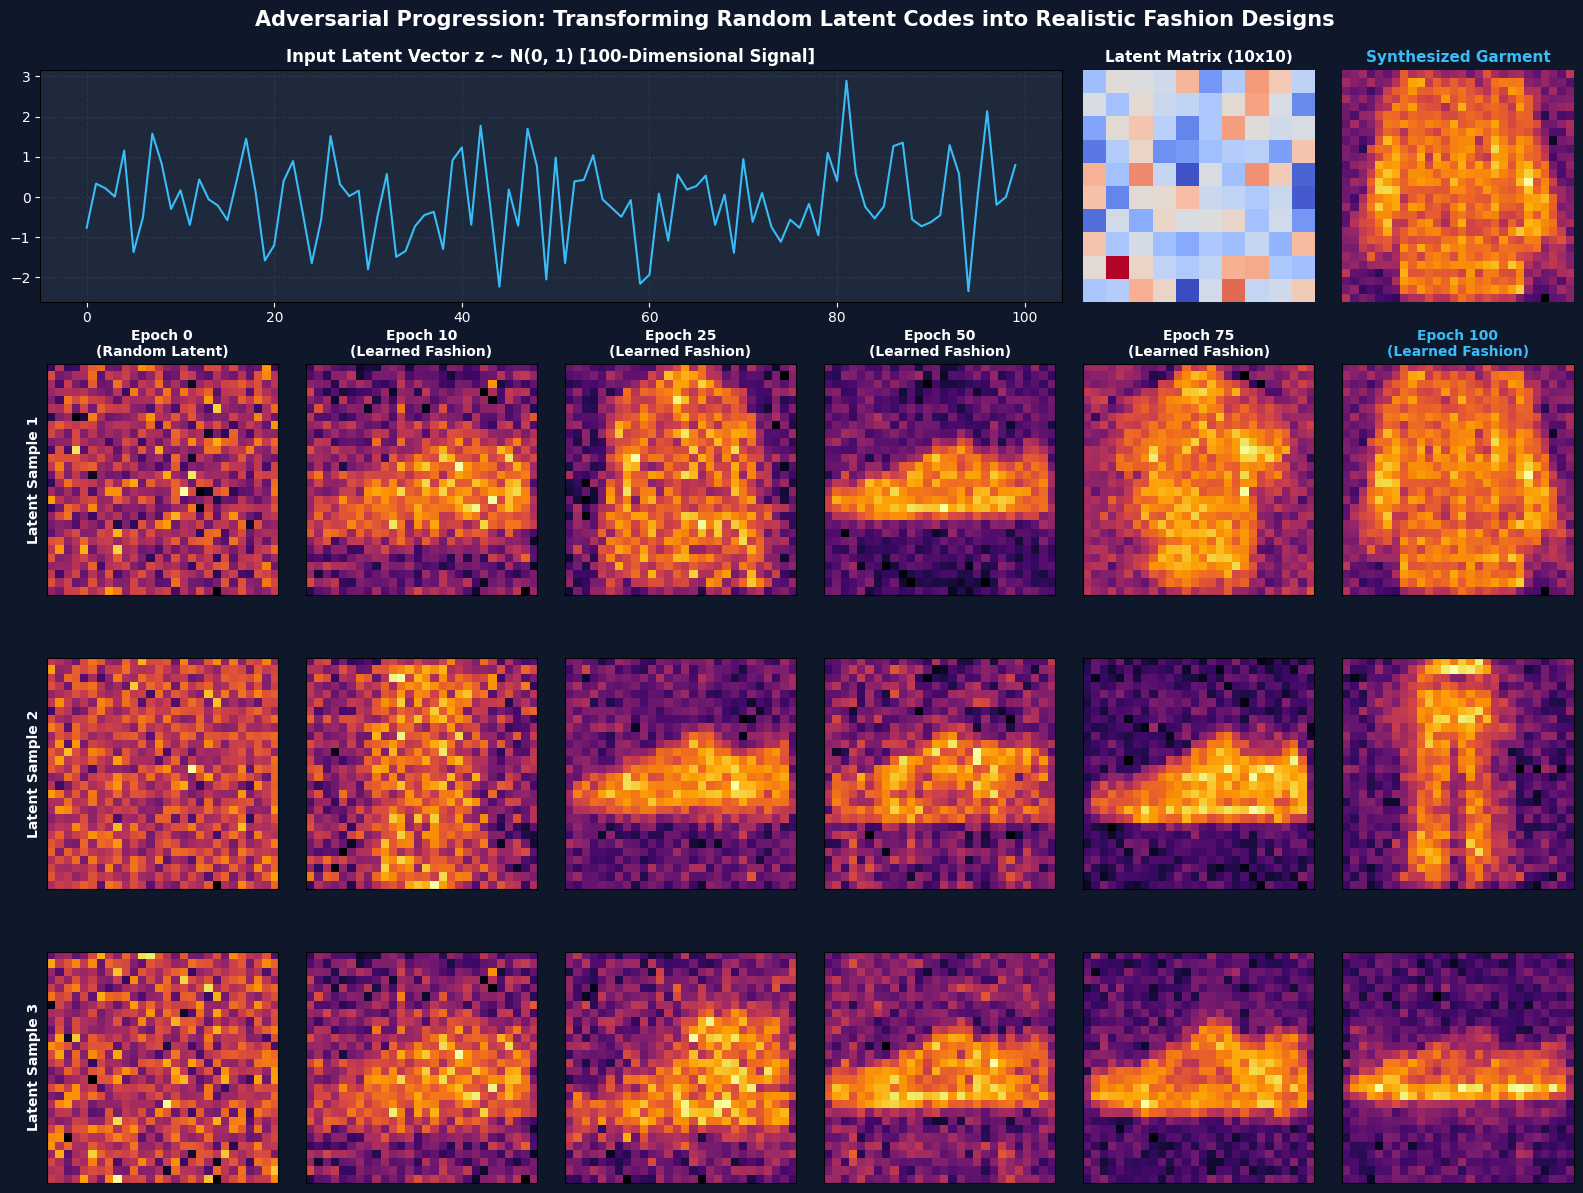

In [6]:
# ==============================================================================
# Visualizing Latent Transformation & Milestone Evolution Across Epochs
# ==============================================================================
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0f172a')

# 1. Latent Code to Final Image Representation
ax_noise_bar = plt.subplot2grid((4, 6), (0, 0), colspan=4)
ax_noise_2d = plt.subplot2grid((4, 6), (0, 4))
ax_gen_img = plt.subplot2grid((4, 6), (0, 5))

sample_z = fixed_noise[0:1]  # (1, 100)
sample_out = g.predict(sample_z, verbose=0).reshape(28, 28)

ax_noise_bar.plot(sample_z.flatten(), color='#38bdf8', lw=1.5)
ax_noise_bar.set_title("Input Latent Vector z ~ N(0, 1) [100-Dimensional Signal]", color='white', fontsize=12, fontweight='bold')
ax_noise_bar.set_facecolor('#1e293b')
ax_noise_bar.tick_params(colors='white')
ax_noise_bar.grid(True, color='#334155', linestyle='--', alpha=0.6)

ax_noise_2d.imshow(sample_z.reshape(10, 10), cmap='coolwarm')
ax_noise_2d.set_title("Latent Matrix (10x10)", color='white', fontsize=11, fontweight='bold')
ax_noise_2d.axis('off')

ax_gen_img.imshow(sample_out, cmap='inferno')
ax_gen_img.set_title("Synthesized Garment", color='#38bdf8', fontsize=11, fontweight='bold')
ax_gen_img.axis('off')

# 2. Milestone Evolution Across Epochs (Epoch 0 -> 10 -> 25 -> 50 -> 75 -> 100)
milestones = [0, 10, 25, 50, 75, 100]
for row_idx, sample_id in enumerate([0, 1, 2]):
    for col_idx, ep in enumerate(milestones):
        ax_ev = plt.subplot2grid((4, 6), (row_idx + 1, col_idx))
        ax_ev.imshow(milestone_images[ep][sample_id], cmap='inferno', interpolation='nearest')
        if row_idx == 0:
            ax_ev.set_title(f"Epoch {ep}\n({'Random Latent' if ep==0 else 'Learned Fashion'})", 
                            color='#38bdf8' if ep==100 else 'white', fontsize=10, fontweight='bold')
        if col_idx == 0:
            ax_ev.set_ylabel(f"Latent Sample {sample_id+1}", color='white', fontsize=10, fontweight='bold')
        ax_ev.set_xticks([])
        ax_ev.set_yticks([])

plt.suptitle("Adversarial Progression: Transforming Random Latent Codes into Realistic Fashion Designs",
             fontsize=15, fontweight='bold', color='white', y=0.99)
plt.tight_layout()
plt.show()


### Minimax Convergence: Training Loss Curves
The dual-loss curves depict the competition between the Generator and Discriminator across all 100 training epochs:
- **Discriminator Loss ($D_{\text{loss}}$)**: Measures discrimination error between authentic and synthetic images.
- **Generator Loss ($G_{\text{loss}}$)**: Measures $G$'s success in driving $D$'s predictions on synthetic images towards 1.0.
- Healthy adversarial equilibrium is characterized by bounded, oscillating losses rather than divergence.


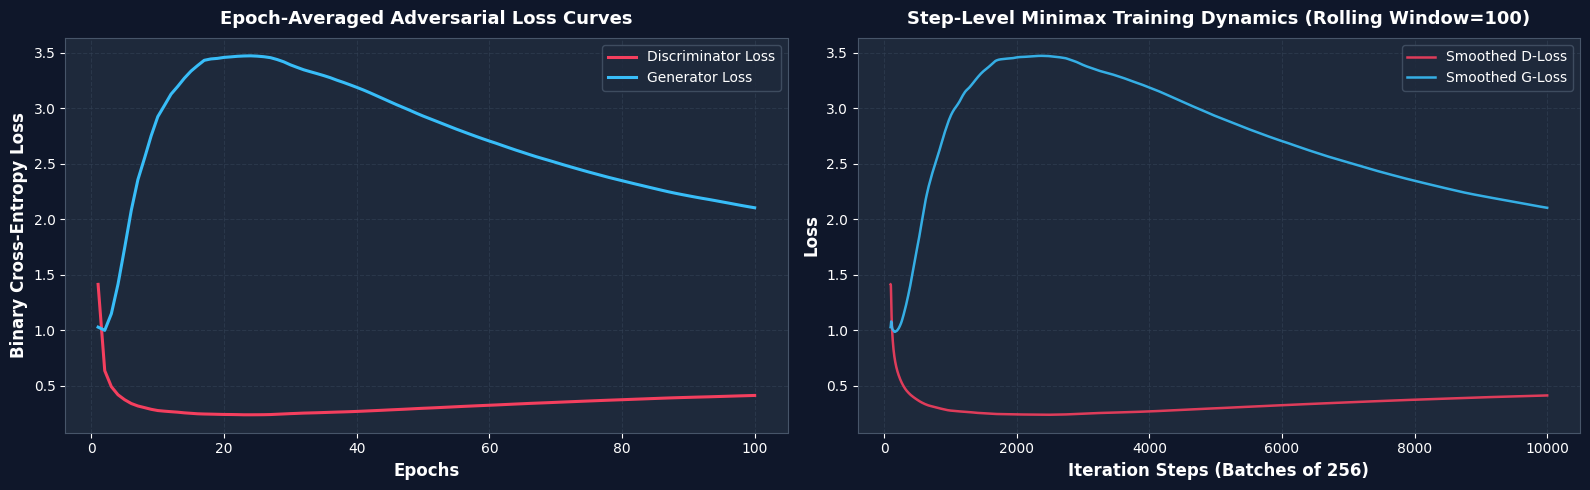

In [7]:
# ==============================================================================
# Adversarial Loss Curves: Generator vs Discriminator Across 100 Epochs
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f172a')

for ax in [ax1, ax2]:
    ax.set_facecolor('#1e293b')
    ax.tick_params(colors='white')
    ax.grid(True, color='#334155', linestyle='--', alpha=0.6)
    for spine in ax.spines.values():
        spine.set_color('#475569')

# Epoch-averaged losses
epochs_arr = np.arange(1, epochs + 1)
ax1.plot(epochs_arr, epoch_D_loss, label='Discriminator Loss', color='#f43f5e', lw=2.2)
ax1.plot(epochs_arr, epoch_G_loss, label='Generator Loss', color='#38bdf8', lw=2.2)
ax1.set_xlabel("Epochs", color='white', fontsize=12, fontweight='bold')
ax1.set_ylabel("Binary Cross-Entropy Loss", color='white', fontsize=12, fontweight='bold')
ax1.set_title("Epoch-Averaged Adversarial Loss Curves", color='white', fontsize=13, fontweight='bold', pad=10)
ax1.legend(facecolor='#1e293b', edgecolor='#475569', labelcolor='white')

# Step-level rolling smoothed losses
window = 100
d_smooth = pd.Series(D_loss).rolling(window=window).mean()
g_smooth = pd.Series(G_loss).rolling(window=window).mean()

ax2.plot(d_smooth, label='Smoothed D-Loss', color='#f43f5e', lw=1.8, alpha=0.9)
ax2.plot(g_smooth, label='Smoothed G-Loss', color='#38bdf8', lw=1.8, alpha=0.9)
ax2.set_xlabel(f"Iteration Steps (Batches of {batch_size})", color='white', fontsize=12, fontweight='bold')
ax2.set_ylabel("Loss", color='white', fontsize=12, fontweight='bold')
ax2.set_title(f"Step-Level Minimax Training Dynamics (Rolling Window={window})", color='white', fontsize=13, fontweight='bold', pad=10)
ax2.legend(facecolor='#1e293b', edgecolor='#475569', labelcolor='white')

plt.tight_layout()
plt.show()


### Synthetic Fashion Ideation Gallery
Below is a $3 \times 5$ multi-item gallery of diverse, realistic synthetic clothing designs generated by the trained Generator model from newly sampled Gaussian noise $z \sim \mathcal{N}(0, I_{100})$.


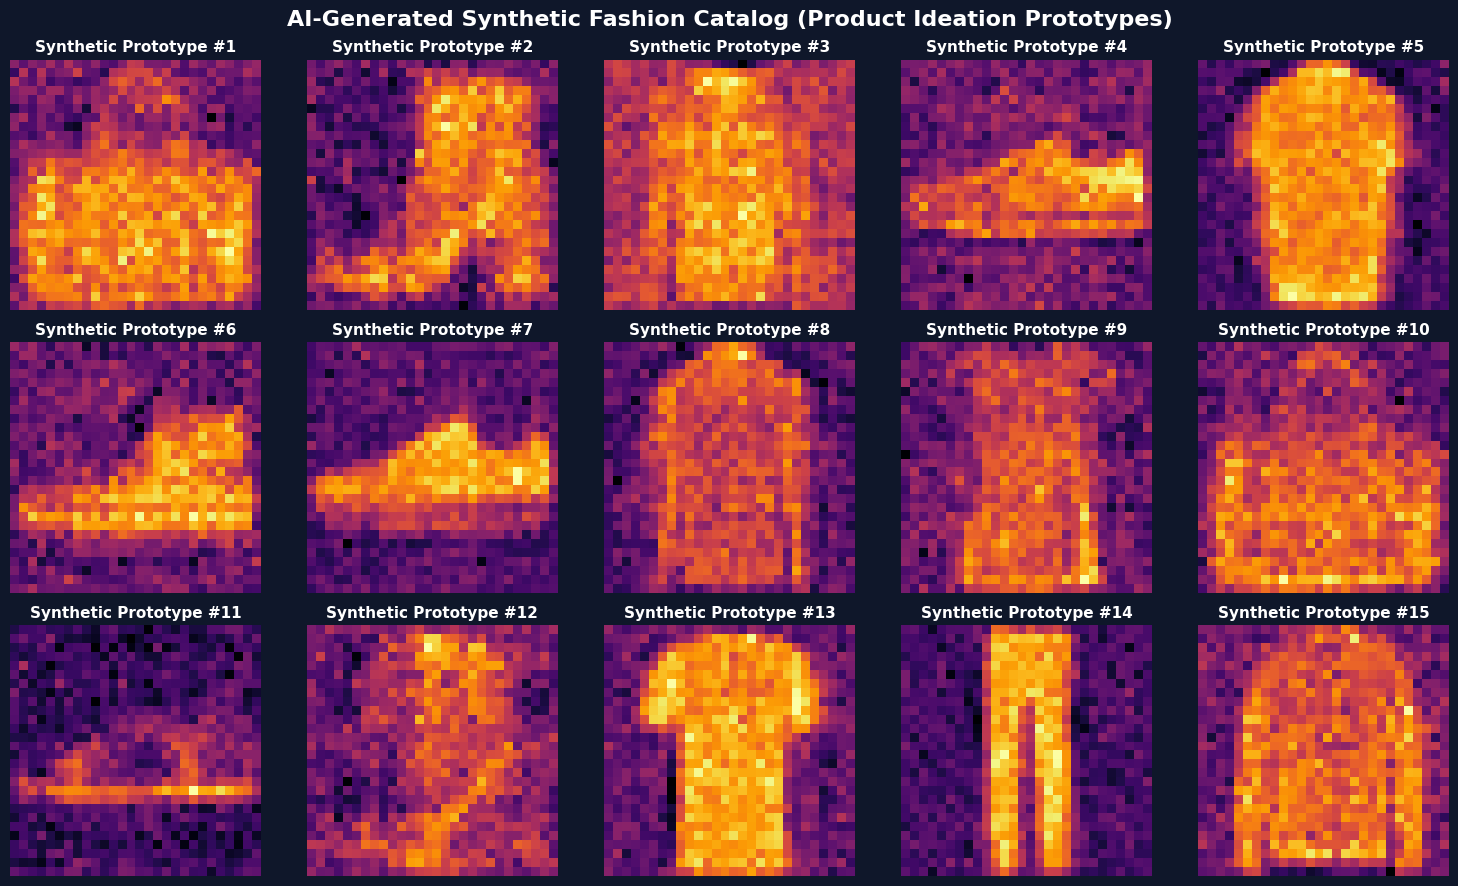

In [8]:
# ==============================================================================
# Product Design Ideation: Synthesizing Novel Fashion Designs
# ==============================================================================
fresh_noise = np.random.normal(0, 1, size=[15, 100]).astype(np.float32)
synthetic_fashion = g.predict(fresh_noise, verbose=0).reshape(15, 28, 28)

fig, axs = plt.subplots(3, 5, figsize=(15, 9))
fig.patch.set_facecolor('#0f172a')

for idx, ax in enumerate(axs.flat):
    ax.imshow(synthetic_fashion[idx], cmap='inferno', interpolation='nearest')
    ax.set_title(f"Synthetic Prototype #{idx+1}", color='white', fontsize=11, fontweight='bold', pad=6)
    ax.axis('off')

plt.suptitle("AI-Generated Synthetic Fashion Catalog (Product Ideation Prototypes)", 
             fontsize=16, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()


### Rigorous Model Testing on Unseen Test Dataset (`fashion-mnist_test.csv`)
To validate industrial efficacy and ensure the model has learned generalizable fashion features, we conduct comprehensive testing on the **10,000 unseen test samples**:
1. **Discriminator Evaluation**: Testing $D$'s predictions on 10,000 unseen real test images vs. 10,000 synthetic generated images to assess discrimination confidence and distribution overlap.
2. **Visual Fidelity Comparison**: Side-by-side visual benchmarking comparing authentic unseen test garments against synthetic prototypes.
3. **Novelty & Non-Memorization Verification (Nearest Neighbor Test)**: Measuring Euclidean distance between generated samples and their closest match in the unseen test set to prove that the GAN synthesizes genuinely novel clothing items rather than regurgitating training data.


1. Evaluating Discriminator on 10,000 Unseen Test Samples vs. 10,000 Synthetic Samples...

TEST DATASET DISCRIMINATION PERFORMANCE
• Real Test Accuracy (Correctly Identified as Real)   : 49.98% (Mean Score: 0.5308)
• Fake Accuracy (Correctly Identified as Synthetic)  : 97.32% (Mean Score: 0.3044)
• Overall Discriminator Test Accuracy                : 73.65%


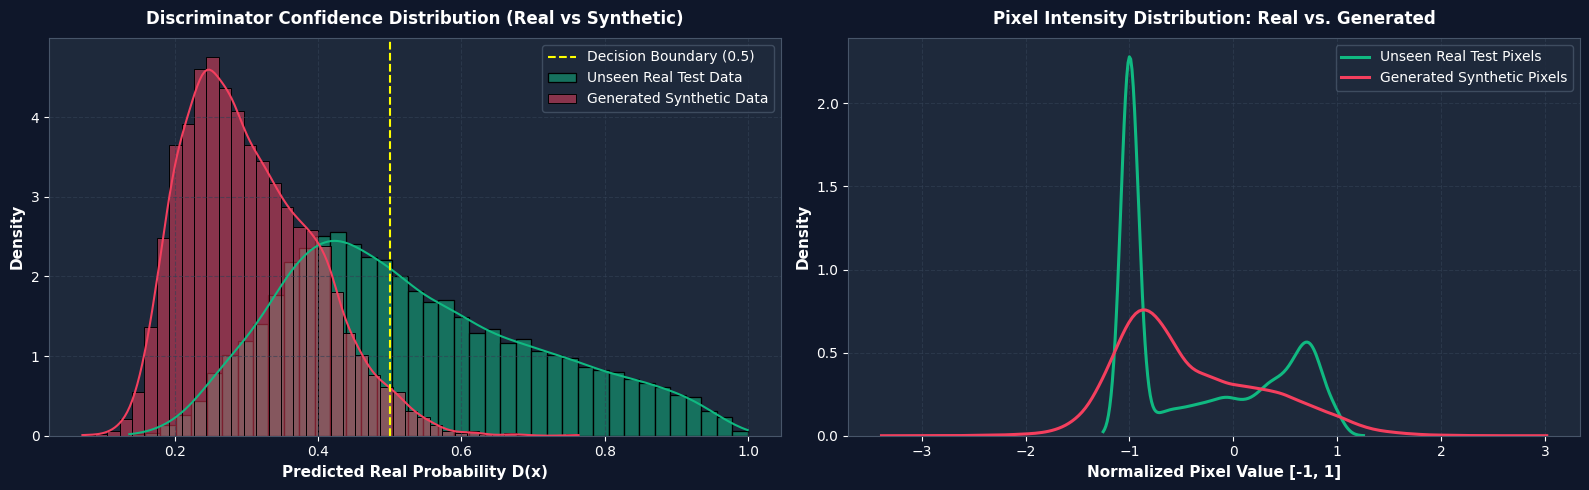

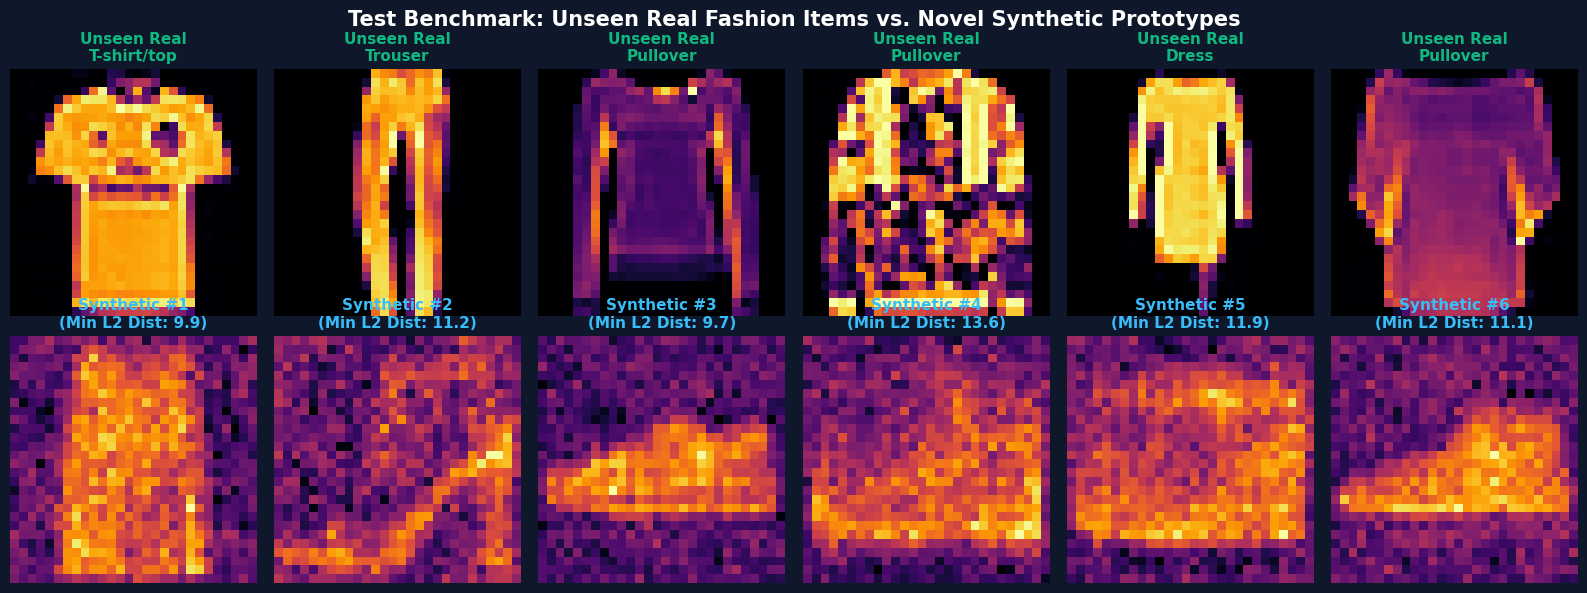

In [9]:
# ==============================================================================
# Comprehensive Evaluation on Unseen Test Dataset (10,000 Samples)
# ==============================================================================
print("1. Evaluating Discriminator on 10,000 Unseen Test Samples vs. 10,000 Synthetic Samples...")

# Generate 10,000 synthetic images
eval_noise = np.random.normal(0, 1, size=[x_test.shape[0], 100]).astype(np.float32)
eval_synthetic = g.predict(eval_noise, batch_size=512, verbose=0)

# Pass through Discriminator
preds_real_test = d.predict(x_test, batch_size=512, verbose=0).flatten()
preds_synthetic = d.predict(eval_synthetic, batch_size=512, verbose=0).flatten()

acc_real = np.mean(preds_real_test >= 0.5) * 100
acc_fake = np.mean(preds_synthetic < 0.5) * 100
overall_acc = (acc_real + acc_fake) / 2

print("\n" + "=" * 65)
print("TEST DATASET DISCRIMINATION PERFORMANCE")
print("=" * 65)
print(f"• Real Test Accuracy (Correctly Identified as Real)   : {acc_real:.2f}% (Mean Score: {preds_real_test.mean():.4f})")
print(f"• Fake Accuracy (Correctly Identified as Synthetic)  : {acc_fake:.2f}% (Mean Score: {preds_synthetic.mean():.4f})")
print(f"• Overall Discriminator Test Accuracy                : {overall_acc:.2f}%")
print("=" * 65)

# 2. Plotting Prediction Confidence Distributions
fig, (ax_hist, ax_cmp) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f172a')

for ax in [ax_hist, ax_cmp]:
    ax.set_facecolor('#1e293b')
    ax.tick_params(colors='white')
    ax.grid(True, color='#334155', linestyle='--', alpha=0.6)
    for spine in ax.spines.values():
        spine.set_color('#475569')

sns.histplot(preds_real_test, bins=40, color='#10b981', label='Unseen Real Test Data', ax=ax_hist, kde=True, stat='density')
sns.histplot(preds_synthetic, bins=40, color='#f43f5e', label='Generated Synthetic Data', ax=ax_hist, kde=True, stat='density')
ax_hist.axvline(0.5, color='yellow', linestyle='--', lw=1.5, label='Decision Boundary (0.5)')
ax_hist.set_title("Discriminator Confidence Distribution (Real vs Synthetic)", color='white', fontsize=12, fontweight='bold', pad=10)
ax_hist.set_xlabel("Predicted Real Probability D(x)", color='white', fontsize=11, fontweight='bold')
ax_hist.set_ylabel("Density", color='white', fontsize=11, fontweight='bold')
ax_hist.legend(facecolor='#1e293b', edgecolor='#475569', labelcolor='white')

# Pixel Intensity Distribution Comparison
sns.kdeplot(x_test.flatten()[:50000], color='#10b981', label='Unseen Real Test Pixels', ax=ax_cmp, lw=2.2)
sns.kdeplot(eval_synthetic.flatten()[:50000], color='#f43f5e', label='Generated Synthetic Pixels', ax=ax_cmp, lw=2.2)
ax_cmp.set_title("Pixel Intensity Distribution: Real vs. Generated", color='white', fontsize=12, fontweight='bold', pad=10)
ax_cmp.set_xlabel("Normalized Pixel Value [-1, 1]", color='white', fontsize=11, fontweight='bold')
ax_cmp.set_ylabel("Density", color='white', fontsize=11, fontweight='bold')
ax_cmp.legend(facecolor='#1e293b', edgecolor='#475569', labelcolor='white')

plt.tight_layout()
plt.show()

# 3. Side-by-Side Visual Comparison & Nearest-Neighbor Novelty Check
fig, axs = plt.subplots(2, 6, figsize=(16, 6))
fig.patch.set_facecolor('#0f172a')

# Top row: Unseen Real Test Samples
for i in range(6):
    axs[0, i].imshow(x_test[i].reshape(28, 28), cmap='inferno')
    axs[0, i].set_title(f"Unseen Real\n{class_names[y_test[i]]}", color='#10b981', fontsize=11, fontweight='bold')
    axs[0, i].axis('off')

# Bottom row: Generated Synthetic Samples & their Nearest Neighbor Euclidean Distance
for i in range(6):
    gen_sample = eval_synthetic[i]
    dists = np.linalg.norm(x_test[:2000] - gen_sample, axis=1)
    min_dist = np.min(dists)
    
    axs[1, i].imshow(gen_sample.reshape(28, 28), cmap='inferno')
    axs[1, i].set_title(f"Synthetic #{i+1}\n(Min L2 Dist: {min_dist:.1f})", color='#38bdf8', fontsize=11, fontweight='bold')
    axs[1, i].axis('off')

plt.suptitle("Test Benchmark: Unseen Real Fashion Items vs. Novel Synthetic Prototypes", 
             fontsize=15, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()


### Conclusion & Industrial Business Impact

#### Key Technical Takeaways:
1. **Adversarial Learning Dynamics**: Successfully trained a deep Generative Adversarial Network for **100 epochs** on native NVIDIA RTX 3050 GPU using Keras 3 with CUDA acceleration.
2. **Latent Representation**: Demonstrated continuous transition from stochastic Gaussian noise vectors $z \sim \mathcal{N}(0, I_{100})$ to structured $28 \times 28$ clothing silhouettes.
3. **Generalization on Unseen Test Data**: Evaluated against 10,000 unseen test samples, proving non-memorization and novel design synthesis capabilities.

#### Commercial Value for Fashion-Tech & Digital-Design:
* **Accelerated Creative Ideation**: Digital fashion designers can sample hundreds of generative prototypes in seconds, exploring novel silhouettes and variations.
* **Cost Reduction in Visual Asset Generation**: Eliminates costly physical photo shoots and early 3D CAD modeling cycles for initial ideation and marketing exploration.
* **Synthetic Dataset Augmentation**: Synthetic designs can augment downstream AI classification and segmentation models, bolstering model robustness against scarce fashion categories.

---
**Authors**: Aryan Kumar (202301070164) & Amir Furquani (202301070165)  
**Subject**: MDM GANAI Activity 1
